In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
    N_HANKEL_COLS,
    N_HANKEL_ROWS,
    N_LATENT_PATH,
    N_MARKOV,
    RANDOM_SEED,
)
from era_utils import build_hankel, collect_markov_parameters
from latent_dim import NOTEBOOK_GITHUB_URL, make_singular_value_figure
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)

In [ ]:
# ── experiment constants ───────────────────────────────────────────────────────
# Singular values below this fraction of the largest are treated as numerical
# zero, indicating latent dimensions that carry no system dynamics.
RELATIVE_THRESHOLD = 1e-6

N_SHOW    = 15          # number of singular values to display in the figure
DATA_PATH = N_LATENT_PATH

In [3]:
# ── derived: Brain interface dimensions ───────────────────────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
Q_DIM = len(_b.measure())
del _b
print(f"n_u = {P_DIM}")
print(f"n_y = {Q_DIM}")

n_u = 2
n_y = 16


In [4]:
# ── simulation: Markov parameters and Hankel singular values ──────────────────
markov = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)
H0, _ = build_hankel(markov, N_HANKEL_ROWS, N_HANKEL_COLS)
sv = np.linalg.svd(H0, compute_uv=False)
SV_NORM = sv / sv[0]

print(f"Hankel matrix shape: {H0.shape}")
print("Normalised singular values (top 10):")
for i, v in enumerate(SV_NORM[:10]):
    print(f"  {i + 1:3d}: {v:.2e}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Hankel matrix shape: (320, 60)
Normalised singular values (top 10):
    1: 1.00e+00
    2: 2.00e-01
    3: 1.02e-01
    4: 4.51e-02
    5: 8.48e-03
    6: 2.89e-03
    7: 2.43e-16
    8: 2.28e-16
    9: 1.89e-16
   10: 1.80e-16


In [5]:
# ── derive number of latent dimensions from threshold ─────────────────────────
N_LATENT = int(np.sum(SV_NORM > RELATIVE_THRESHOLD))
print(
    f"n_x = {N_LATENT}  "
    f"(threshold = {RELATIVE_THRESHOLD:.0e} x sv[0])"
)

n_x = 6  (threshold = 1e-06 x sv[0])


In [6]:
# ── save number of latent dimensions ──────────────────────────────────────────
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(DATA_PATH, n_latent=np.array(N_LATENT))
print(f"Saved n_latent = {N_LATENT} to {DATA_PATH.resolve()}")

Saved n_latent = 6 to /Users/tahmidazam/Developer/gg4/data/latent_dim.npz


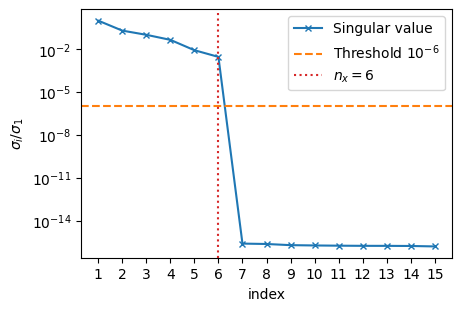

In [7]:
# ── figure: singular value decay ──────────────────────────────────────────────
configure_screen()
fig = make_singular_value_figure(
    SV_NORM, N_LATENT, RELATIVE_THRESHOLD, N_SHOW, figsize=(4.5, 3.0)
)
plt.show()

In [8]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC = 0.5   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.12  # fraction of A4 content height

configure_pgf()
fig = make_singular_value_figure(
    SV_NORM, N_LATENT, RELATIVE_THRESHOLD, N_SHOW,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "latent_dim.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/latent_dim.pgf


In [9]:
# ── caption ────────────────────────────────────────────────────────────────────
exp = int(np.floor(np.log10(RELATIVE_THRESHOLD)))
caption = (
    r"Normalised singular values $\sigma_i / \sigma_1$ of the block Hankel matrix "
    r"constructed from "
    + str(N_MARKOV)
    + r" noise-free Markov parameters ($"
    + str(N_HANKEL_ROWS)
    + r"$ block rows, $"
    + str(N_HANKEL_COLS)
    + r"$ block columns, $n_u = "
    + str(P_DIM)
    + r"$ inputs, $n_y = "
    + str(Q_DIM)
    + r"$ outputs). "
    r"The orange dashed line marks the relative threshold $10^{"
    + str(exp)
    + r"}$; singular values below this level are indistinguishable from numerical "
    r"zero under exact noise cancellation. "
    r"The red dotted line indicates $n_x = "
    + str(N_LATENT)
    + r"$."
)
save_caption(CAPTIONS_PATH / "latent_dim.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/latent_dim.tex
Normalised singular values $\sigma_i / \sigma_1$ of the block Hankel matrix constructed from 55 noise-free Markov parameters ($20$ block rows, $30$ block columns, $n_u = 2$ inputs, $n_y = 16$ outputs). The orange dashed line marks the relative threshold $10^{-6}$; singular values below this level are indistinguishable from numerical zero under exact noise cancellation. The red dotted line indicates $n_x = 6$.
